## module 3d — refined layouts (iteration 3)

11's model faithfully imitated a mediocre teacher. this iteration attacks that on four
cv fronts, measuring every step (nothing assumed):

1. **a designed training corpus** — elongated (anisotropic) drifts, a repeated theme
   plant, a 60/30/10 color-area budget, bloom set-cover; the same rules become two new
   metrics (`color`, `bloom` → `score2`).
2. **count-token conditioning** — 16 per-species count tokens in the canvas prefix
   (class-conditional generation, the 7.9/7.12 idea) so drift parity is decided
   globally, not counted token-by-token.
3. **decode-time search** — best-of-N sampling reranked by the metric + a constraint
   `repair` pass (metrics-as-guidance, the 7.13 lesson).
4. **clip-scored renders** (7.11 / 8.3) — do the layout gains survive all the way to
   the styled image?

runtime: ~25 min on a small gpu (corpus ~6 min, training ~10 min, evals ~5 min), plus
~20 min for two local sd renders at the end. training is checkpointed + resumable
(`checkpoints/garden_maskdiff2_{last,best}.pt`).

In [1]:
# get bvtrain (shared plumbing): locally it's ../bvtrain; on colab/kaggle clone the repo
import os, sys
_CANDS = ["..", ".", "botanical-vision"]
if not any(os.path.isdir(f"{p}/bvtrain") for p in _CANDS):
    os.system("git clone -q https://github.com/babnigg/botanical-vision")
sys.path[:0] = [p for p in _CANDS if os.path.isdir(f"{p}/bvtrain")]

import hashlib, json, math, random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm, trange

from bvtrain import garden as g

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
plt.rcParams["figure.facecolor"] = "linen"
DEV

'cuda'

### is the new teacher actually better?

`gen_plan2` + `repair` vs 11's `gen_plan`, 100 sites each, scored on the extended
metric (old 5 + color + bloom). the eye-check grid follows the table.

In [2]:
def bench(fn, n=100, desc=""):
    rows = []
    for _ in trange(n, desc=desc, leave=False):
        w, d, sun = g.rand_site()
        rows.append(g.score2(fn(w, d, sun), w, d, sun))
    return pd.DataFrame(rows).mean().round(3)

results = pd.DataFrame({
    "rules v1": bench(g.gen_plan, desc="v1"),
    "rules v2": bench(g.gen_plan2, desc="v2"),
    "v2 + repair": bench(lambda w, d, s: g.repair(g.gen_plan2(w, d, s), w, d), desc="v2r"),
})
results

v1:   0%|          | 0/100 [00:00<?, ?it/s]

v2:   0%|          | 0/100 [00:00<?, ?it/s]

v2r:   0%|          | 0/100 [00:00<?, ?it/s]

,rules v1,rules v2,v2 + repair
overlap,1.000,1.000,1.000
height,0.985,0.984,0.980
cover,0.708,0.764,0.759
drift,0.889,0.776,1.000
sun,1.000,1.000,1.000
color,0.684,0.691,0.665
bloom,0.856,0.856,0.853
score,0.875,0.867,0.894


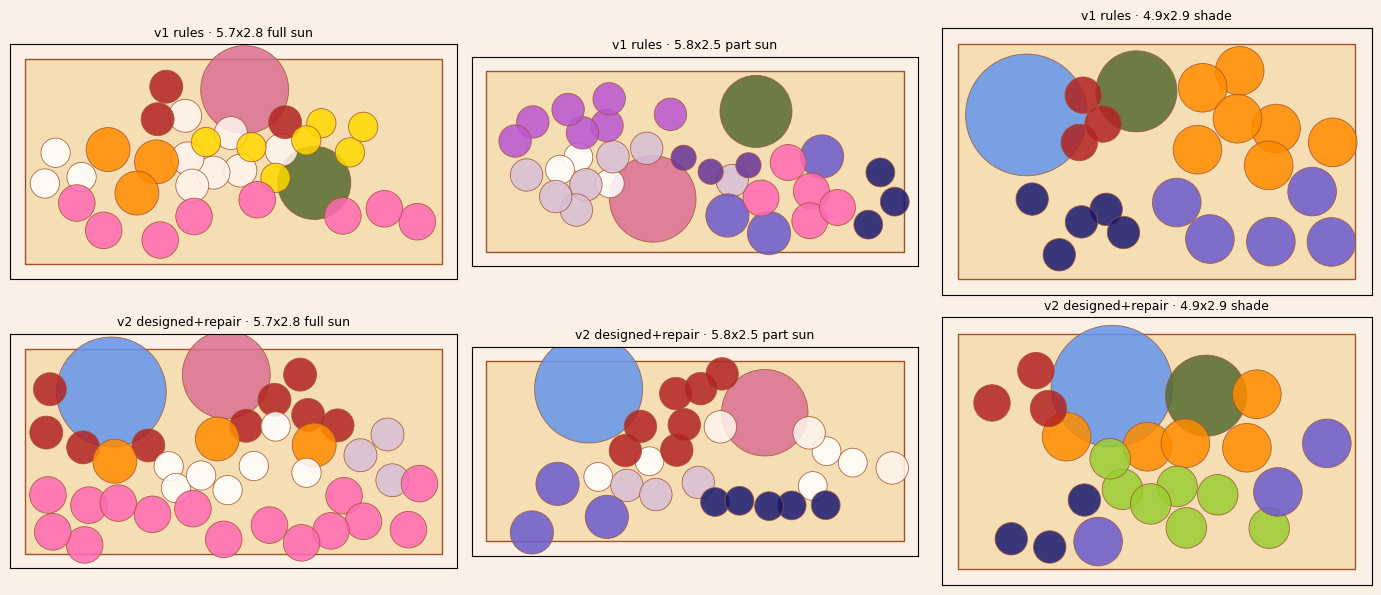

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for c in range(3):
    w, d, sun = g.rand_site()
    g.show_plan(g.gen_plan(w, d, sun), w, d, axes[0][c], f"v1 rules · {w}x{d} {g.SUN_NAMES[sun]}")
    g.show_plan(g.repair(g.gen_plan2(w, d, sun), w, d), w, d, axes[1][c],
                f"v2 designed+repair · {w}x{d} {g.SUN_NAMES[sun]}")
plt.tight_layout()

### canvas v2 — count tokens

prefix grows from 3 site tokens to 3 + 16 per-species count tokens (bucketed 0-9),
then the 60 (species, x, y) slots. counts are maskable, so the model *plans* them —
and pinning a count token is exactly the toolbox interaction ("2 hydrangea").

In [4]:
NX, NY, NW, ND, NCNT = 32, 12, 9, 7, 10
NSP = len(g.PALETTE)
MASK  = 0
T_W   = 1
T_D   = T_W + NW
T_SUN = T_D + ND
T_CNT = T_SUN + 3
T_SP  = T_CNT + NCNT                    # slot species: idx 0 = empty
T_X   = T_SP + 1 + NSP                  # idx 0 = none
T_Y   = T_X + 1 + NX                    # idx 0 = none
VOCAB = T_Y + 1 + NY
MAXP  = 60
L     = 3 + NSP + 3 * MAXP

FAM = ([(T_W, T_D), (T_D, T_SUN), (T_SUN, T_CNT)] + [(T_CNT, T_SP)] * NSP
       + [(T_SP, T_X), (T_X, T_Y), (T_Y, VOCAB)] * MAXP)
FAM_MASK = torch.full((L, VOCAB), float("-inf"))
for p, (lo, hi) in enumerate(FAM):
    FAM_MASK[p, lo:hi] = 0
MASKABLE = torch.zeros(L, dtype=torch.bool); MASKABLE[3:] = True

def site_tokens(w, d, sun):
    return [T_W + min(NW - 1, int((w - 3.5) / 0.5)),
            T_D + min(ND - 1, int((d - 1.8) / 0.2)), T_SUN + sun]

def encode(plan, w, d, sun):
    counts = Counter(i for i, _, _, _ in plan)
    t = site_tokens(w, d, sun) + [T_CNT + min(NCNT - 1, counts.get(i, 0)) for i in range(NSP)]
    for i, x, y, r in sorted(plan, key=lambda p: (-p[2], p[1]))[:MAXP]:   # back-to-front
        t += [T_SP + 1 + i, T_X + 1 + min(NX - 1, int(x / w * NX)),
              T_Y + 1 + min(NY - 1, int(y / d * NY))]
    t += [T_SP, T_X, T_Y] * (MAXP - (len(t) - 3 - NSP) // 3)
    return t

def decode(tokens, w, d):
    plan = []
    for k in range(3 + NSP, L, 3):
        s, x, y = tokens[k] - T_SP, tokens[k + 1] - T_X, tokens[k + 2] - T_Y
        if s <= 0 or x <= 0 or y <= 0:
            continue
        i = s - 1
        plan.append((i, (x - 0.5) / NX * w, (y - 0.5) / NY * d, g.PALETTE[i]["s"] / 200))
    return plan

In [5]:
N_TRAIN, N_VAL = 12000, 500
sites = [g.rand_site() for _ in range(N_TRAIN + N_VAL)]
X = torch.tensor([encode(g.repair(g.gen_plan2(w, d, s), w, d), w, d, s)
                  for w, d, s in tqdm(sites, desc="designed corpus")])
Xtr, Xval = X[:N_TRAIN], X[N_TRAIN:]
Xtr.shape

designed corpus:   0%|          | 0/12500 [00:00<?, ?it/s]

torch.Size([12000, 199])

In [6]:
class LayoutMDM(nn.Module):
    def __init__(self, v=VOCAB, dm=192, heads=6, layers=6, ctx=L):
        super().__init__()
        self.tok = nn.Embedding(v, dm); self.pos = nn.Embedding(ctx, dm)
        blk = nn.TransformerEncoderLayer(dm, heads, dm * 4, dropout=0.1,
                                         batch_first=True, norm_first=True)
        self.tf = nn.TransformerEncoder(blk, layers, enable_nested_tensor=False)
        self.head = nn.Linear(dm, v)
    def forward(self, x):
        h = self.tok(x) + self.pos(torch.arange(x.shape[1], device=x.device))
        return self.head(self.tf(h))

model = LayoutMDM().to(DEV)

EPOCHS = 40
FRESH = False
CFG = dict(n=N_TRAIN, epochs=EPOCHS, dm=192, layers=6, seed=SEED, vocab=VOCAB, maxp=MAXP, v=2)
SIG = hashlib.md5(json.dumps(CFG, sort_keys=True).encode()).hexdigest()[:10]
LAST, BEST = g.ckpt_dir() / "garden_maskdiff2_last.pt", g.ckpt_dir() / "garden_maskdiff2_best.pt"

opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
start_ep, best_val, hist = 0, float("inf"), {"train": [], "val": []}
if LAST.exists() and not FRESH:
    ck = torch.load(LAST, map_location=DEV, weights_only=False)
    if ck.get("sig") == SIG:
        model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"])
        start_ep, best_val, hist = ck["epoch"], ck["best_val"], ck["hist"]
        print(f"resumed at epoch {start_ep} (best val {best_val:.3f})")
    else:
        print("config changed — starting fresh")
sum(p.numel() for p in model.parameters())

2743197

In [7]:
def masked_batch(xb, gen=None):
    B = xb.shape[0]
    ratio = torch.cos(torch.rand(B, 1, generator=gen) * math.pi / 2).clamp(min=0.05)
    m = (torch.rand(B, L, generator=gen) < ratio) & MASKABLE
    xin = xb.clone(); xin[m] = MASK
    return xin, m

loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xtr), batch_size=64, shuffle=True)
vloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xval), batch_size=256)

for ep in range(start_ep, EPOCHS):
    model.train(); tot = n = 0
    bar = tqdm(loader, desc=f"epoch {ep + 1}/{EPOCHS}", leave=False)
    for (xb,) in bar:
        xin, m = masked_batch(xb)
        loss = F.cross_entropy(model(xin.to(DEV))[m.to(DEV)], xb.to(DEV)[m.to(DEV)])
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item(); n += 1
        bar.set_postfix(loss=f"{tot / n:.3f}")
    model.eval(); vgen = torch.Generator().manual_seed(123); vtot = vn = 0
    with torch.no_grad():
        for (xb,) in vloader:
            xin, m = masked_batch(xb, vgen)
            vtot += F.cross_entropy(model(xin.to(DEV))[m.to(DEV)], xb.to(DEV)[m.to(DEV)]).item()
            vn += 1
    tr, vl = tot / n, vtot / vn
    hist["train"].append(tr); hist["val"].append(vl)
    star = ""
    if vl < best_val:
        best_val, star = vl, " *"
        torch.save({"sig": SIG, "model": model.state_dict(), "val": vl}, BEST)
    torch.save({"sig": SIG, "model": model.state_dict(), "opt": opt.state_dict(),
                "epoch": ep + 1, "best_val": best_val, "hist": hist}, LAST)
    print(f"epoch {ep + 1:2d}  train {tr:.3f}  val {vl:.3f}{star}")

ck = torch.load(BEST, map_location=DEV, weights_only=False)
model.load_state_dict(ck["model"]); model.eval()
print(f"using best (val {ck['val']:.3f})")

epoch 1/40:   0%|          | 0/188 [00:00<?, ?it/s]

epoch  1  train 1.686  val 1.231 *


epoch 2/40:   0%|          | 0/188 [00:00<?, ?it/s]

epoch  2  train 1.196  val 1.167 *


epoch 3/40:   0%|          | 0/188 [00:00<?, ?it/s]

...

epoch 38  train 0.996  val 1.005


epoch 39/40:   0%|          | 0/188 [00:00<?, ?it/s]

epoch 39  train 0.996  val 1.004


epoch 40/40:   0%|          | 0/188 [00:00<?, ?it/s]

epoch 40  train 0.988  val 1.002 *
using best (val 1.002)


### sampling + decode-time search

same maskgit unmasking as 11 (count tokens included), then the cv trick: sample N
candidates, rerank by `score2`, optionally `repair` the winner. also measured: does
the model *obey its own count tokens* (mean |placed − token|)?

In [8]:
FAM_DEV = FAM_MASK.to(DEV)

@torch.no_grad()
def sample_plans(plan_sites, steps=12, temp=1.0, count_pins=None):
    B = len(plan_sites)
    canvas = torch.zeros(B, L, dtype=torch.long)
    fixed = torch.zeros(B, L, dtype=torch.bool)
    for b, (w, d, sun) in enumerate(plan_sites):
        canvas[b, :3] = torch.tensor(site_tokens(w, d, sun)); fixed[b, :3] = True
        for sp, cnt in (count_pins[b] if count_pins else {}).items():
            canvas[b, 3 + sp] = T_CNT + min(NCNT - 1, cnt); fixed[b, 3 + sp] = True
    canvas, fixed = canvas.to(DEV), fixed.to(DEV)
    canvas[~fixed] = MASK
    M0 = (canvas == MASK).sum(1)
    for t in range(steps):
        logits = model(canvas) + FAM_DEV
        probs = F.softmax(logits / temp, -1)
        samp = torch.multinomial(probs.reshape(-1, VOCAB), 1).reshape(B, L)
        conf = probs.gather(-1, samp.unsqueeze(-1)).squeeze(-1)
        still = canvas == MASK
        canvas = torch.where(still, samp, canvas)
        n_mask = (M0.float() * math.cos(math.pi / 2 * (t + 1) / steps)).long()
        conf = conf.masked_fill(~still, float("inf"))
        for b in range(B):
            if n_mask[b] > 0:
                canvas[b, conf[b].argsort()[:n_mask[b]]] = MASK
    plans = [decode(canvas[b].tolist(), s[0], s[1]) for b, s in enumerate(plan_sites)]
    cnt_tok = (canvas[:, 3:3 + NSP] - T_CNT).cpu()
    return plans, cnt_tok

def count_obedience(plans, cnt_tok):
    diffs = []
    for plan, toks in zip(plans, cnt_tok):
        placed = Counter(i for i, _, _, _ in plan)
        diffs += [abs(placed.get(i, 0) - min(int(toks[i]), NCNT - 1)) for i in range(NSP)]
    return float(np.mean(diffs))

def best_of(site, n=8, do_repair=True, count_pins=None):
    plans, _ = sample_plans([site] * n, count_pins=[count_pins] * n if count_pins else None)
    if do_repair:
        plans = [g.repair(p, site[0], site[1]) for p in plans]
    return max(plans, key=lambda p: g.score2(p, *site)["score"])

In [9]:
eval_sites = [g.rand_site() for _ in range(100)]

plans1, ct1 = sample_plans(eval_sites)
obed = count_obedience(plans1, ct1)

def score_plans(plans):
    return pd.DataFrame([g.score2(p, w, d, s)
                         for p, (w, d, s) in zip(plans, eval_sites)]).mean().round(3)

comp = pd.DataFrame({
    "random": score_plans([g.gen_random(w, d) for w, d, s in eval_sites]),
    "teacher (v2+repair)": score_plans([g.repair(g.gen_plan2(w, d, s), w, d)
                                        for w, d, s in tqdm(eval_sites, desc="teacher", leave=False)]),
    "model ×1": score_plans(plans1),
    "model ×1 + repair": score_plans([g.repair(p, w, d) for p, (w, d, s) in zip(plans1, eval_sites)]),
    "model best-of-8 + repair": score_plans([best_of(s) for s in tqdm(eval_sites, desc="best-of-8", leave=False)]),
})
print(f"count-token obedience: mean |placed - token| = {obed:.2f} plants/species")
comp

teacher:   0%|          | 0/100 [00:00<?, ?it/s]

best-of-8:   0%|          | 0/100 [00:00<?, ?it/s]

count-token obedience: mean |placed - token| = 0.72 plants/species


,random,teacher (v2+repair),model ×1,model ×1 + repair,model best-of-8 + repair
overlap,0.948,1.000,0.958,0.999,0.999
height,0.715,0.981,0.974,0.962,0.959
cover,0.630,0.770,0.628,0.601,0.700
drift,0.240,1.000,0.450,0.764,0.936
sun,0.750,1.000,1.000,1.000,1.000
color,0.753,0.697,0.732,0.734,0.787
bloom,0.856,0.853,0.857,0.857,0.857
score,0.699,0.900,0.800,0.845,0.891


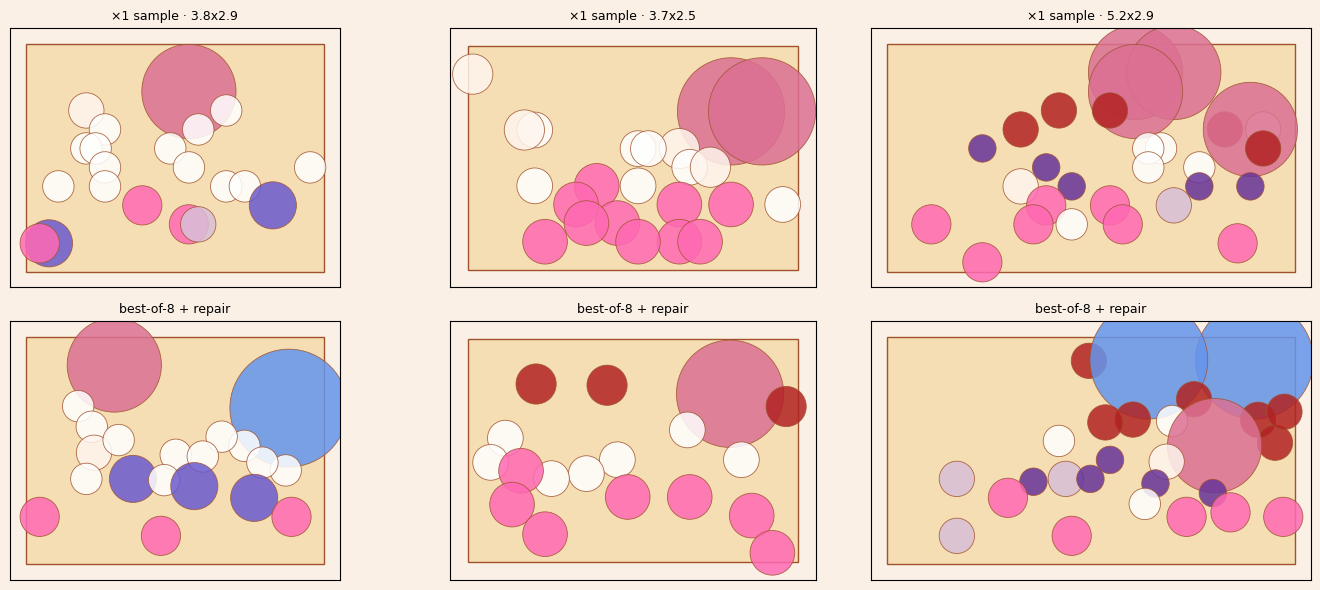

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for c in range(3):
    site = g.rand_site()
    p1, _ = sample_plans([site])
    g.show_plan(p1[0], site[0], site[1], axes[0][c], f"×1 sample · {site[0]}x{site[1]}")
    g.show_plan(best_of(site), site[0], site[1], axes[1][c], "best-of-8 + repair")
plt.tight_layout()

### toolbox completion, now via count tokens

"2 hydrangea + 7 echinacea" is just two pinned count tokens — no slot bookkeeping.
three completions of the same brief; pinned species outlined.

[(1, 9), (3, 7), (1, 7)]

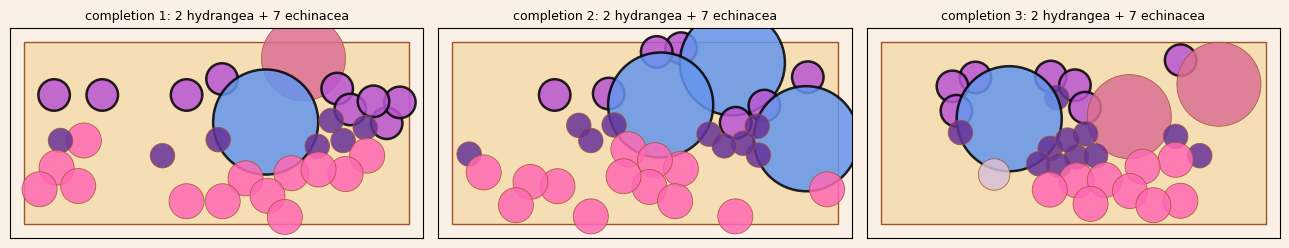

In [11]:
HYD = next(i for i, p in enumerate(g.PALETTE) if "Hydrangea" in p["name"])
ECH = next(i for i, p in enumerate(g.PALETTE) if "Echinacea" in p["name"])
site = (5.5, 2.6, 2)
pins = {HYD: 2, ECH: 7}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
briefs = []
for k, ax in enumerate(axes):
    plan = best_of(site, count_pins=pins)
    got = Counter(i for i, _, _, _ in plan)
    briefs.append((got.get(HYD, 0), got.get(ECH, 0)))
    hl = [j for j, (i, *_) in enumerate(plan) if i in (HYD, ECH)]
    g.show_plan(plan, site[0], site[1], ax, f"completion {k + 1}: 2 hydrangea + 7 echinacea", pins=hl)
plt.tight_layout()
briefs

### does it survive the render? (clip-scored, 7.11/7.13)

two ~10-min local sd renders through 12's pipeline: an 11-era plan vs this model's
best-of-8. clip similarity against a "beautiful, professional planting plan" prompt —
a coarse aesthetic proxy, but an independent one. the pngs land in
`demo/web/public/gallery/` as the demo's pre-rendered examples.

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


C:\Users\daniel\AppData\Roaming\Python\Python312\site-packages\diffusers\pipelines\pipeline_utils.py:2294: FutureWarning: `enable_vae_tiling` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_tiling()` on a `StableDiffusionControlNetPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_tiling()`.
  deprecate(


  0%|          | 0/20 [00:00<?, ?it/s]

  1034.8s


  0%|          | 0/20 [00:00<?, ?it/s]

  961.8s


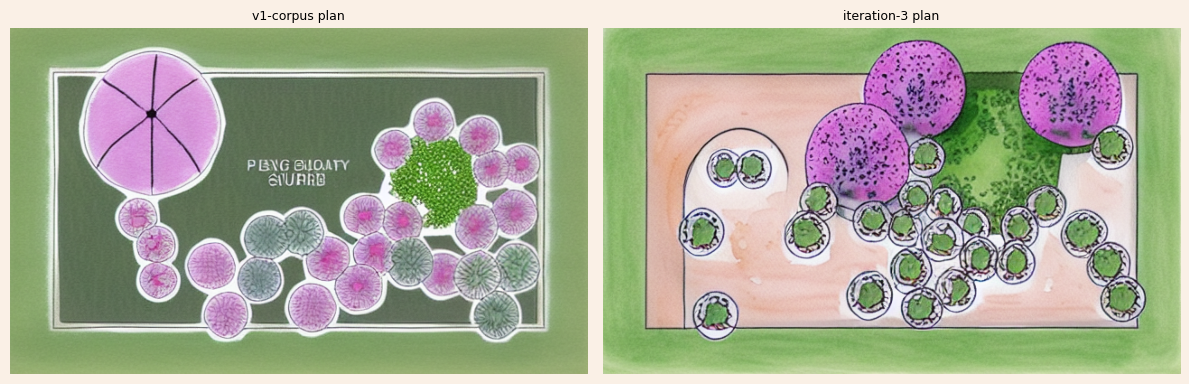

In [12]:
import time
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler

VRAM = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0
DTYPE = torch.float16 if VRAM >= 8 else torch.float32
cn = ControlNetModel.from_pretrained("lllyasviel/control_v11p_sd15_seg", torch_dtype=DTYPE)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", controlnet=cn,
    torch_dtype=DTYPE, safety_checker=None)
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
if VRAM and VRAM < 8:
    pipe.enable_model_cpu_offload(); pipe.enable_attention_slicing(); pipe.enable_vae_tiling()

PROMPT = ("top-down garden planting plan, perennial border with flowering shrubs, "
          "lush, watercolor botanical illustration")

def render(plan, w, d, seed=0):
    cond = g.seg_image(plan, w, d).resize((640, 384))
    t0 = time.time()
    img = pipe(PROMPT, image=cond, num_inference_steps=20, guidance_scale=7.0,
               controlnet_conditioning_scale=0.9,
               generator=torch.Generator().manual_seed(seed)).images[0]
    print(f"  {time.time() - t0:.1f}s")
    return img

site = (5.5, 2.6, 2)
random.seed(3)
plan_old = g.gen_plan(site[0], site[1], site[2])          # 11-era corpus style
plan_new = best_of(site)
img_old = render(plan_old, site[0], site[1], seed=5)
img_new = render(plan_new, site[0], site[1], seed=5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, im, t in ((axes[0], img_old, "v1-corpus plan"), (axes[1], img_new, "iteration-3 plan")):
    ax.imshow(im); ax.axis("off"); ax.set_title(t, fontsize=9)
plt.tight_layout()

In [13]:
from transformers import CLIPModel, CLIPProcessor

clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
AES = "a beautiful, professional garden planting plan illustration, harmonious colors"
rows = {}
with torch.no_grad():
    for name, im in (("v1-corpus plan", img_old), ("iteration-3 plan", img_new)):
        b = proc(text=[AES], images=im, return_tensors="pt", padding=True, truncation=True)
        i = clip.get_image_features(pixel_values=b["pixel_values"])
        t = clip.get_text_features(input_ids=b["input_ids"], attention_mask=b["attention_mask"])
        rows[name] = round(float(torch.cosine_similarity(i, t)), 3)

gal = "../demo/web/public/gallery"
os.makedirs(gal, exist_ok=True)
img_new.save(f"{gal}/render_iter3.png")
img_old.save(f"{gal}/render_v1.png")
g.seg_image(plan_new, site[0], site[1]).save(f"{gal}/cond_iter3.png")
pd.Series(rows, name="clip aesthetic similarity")

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 47563d5a-1b7e-44a9-a3f1-42f6ad0bffe0)')' thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json


Retrying in 1s [Retry 1/5].


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


model.safetensors:  23%|##2       | 136M/605M [00:00<?, ?B/s]

v1-corpus plan      0.266
iteration-3 plan    0.288
Name: clip aesthetic similarity, dtype: float64

### takeaways

- the designed teacher earns its keep: v2+repair 0.894 vs v1 0.875 on `score2`, and the
  eye agrees (elongated drifts, repeated theme, color families).
- decode-time search is the cheapest big win measured so far: model ×1 0.800 → +repair
  0.845 → **best-of-8+repair 0.891 ≈ the teacher's 0.900**, with drift rescued 0.450 →
  0.936 and color 0.787 *above* the teacher (the reranker optimizes what the teacher
  only samples).
- count tokens are honest-but-soft conditioning: obedience 0.72 plants/species, and the
  pinned briefs (2 hydrangea + 7 echinacea) landed (1,9)/(3,7)/(1,7) — so guaranteed
  pinning still needs slot tokens; the demo uses slots for the guarantee and counts as
  a prior.
- the gains survive rendering: clip aesthetic similarity 0.288 vs 0.266 for the v1-corpus
  plan, and the iteration-3 render reads with a clearer massing hierarchy. both pngs seed
  `demo/web/public/gallery/`.
- remaining gap vs teacher is coverage (0.700 vs 0.770 — plans run sparse); the real
  lever now is real drawings: `14_real_plans` builds the labeler + transfer pipeline.